# Ovarian cancer OS — LASSO-Cox on TCGA-OV

First real prognosis model: **overall survival from tumor gene expression**,
trained on TCGA-OV RNA-seq and checked on independent microarray cohorts.

| Split | Cohort | Endpoint |
|---|---|---|
| Train | TCGA-OV HiSeqV2 (~300 primary tumours) | OS days + vital status |
| External | GSE26712 Bonome (185 late-stage tumours) | survival years + DOD |
| External | GSE14764 (80 tumours) | OS time (months) + event |

GSE9891 (Tothill) is the other planned validator, but the GEO series matrix has
no follow-up — that wait is on attaching curated survival, not on this model.

Compared against a **clinical-only Cox** (age, stage, residual disease). The
question is whether expression adds anything.

This is LASSO-Cox, not a neural net. A GPU is optional; CPU is enough.

**Before running**

1. Locally: `.venv/bin/python agent/scripts/colab_check.py --dataset tcga-ov-xena-rna-seq-hiseqv2 --dataset tcga-ov-xena-clinical-matrix --dataset gse26712-ovarian-expression-series-matrix --dataset gse14764-ovarian-expression-series-matrix`
2. In Cursor: *Select Kernel* → *Colab* → *New Colab Server* (GPU or CPU).
3. Private repo: Colab secret `GITHUB_TOKEN` with notebook access on.


## 1. Bootstrap

Puts this repo on the runtime and imports `colab_env`. Same cell as the smoke
test — shallow, blobless, sparse clone, then datasets are fetched on demand.


In [10]:
# Mirrors .research/config.yaml -> colab
REPO, BRANCH, DEST = "github.com/XooTB/research.git", "main", "/content/research"
SPARSE = ["agent", ".research", "docs", "notebooks"]
TOKEN_SECRET = "GITHUB_TOKEN"

import importlib
import pathlib
import subprocess
import sys


def on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


if on_colab():
    token = ""
    try:
        from google.colab import userdata
        token = userdata.get(TOKEN_SECRET) or ""
    except Exception:
        pass  # public repo, or the secret isn't shared with this notebook

    url = f"https://{token + '@' if token else ''}{REPO}"
    dest = pathlib.Path(DEST)
    if not (dest / ".git").exists():
        try:
            subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none",
                            "--sparse", "--branch", BRANCH, url, DEST],
                           check=True, capture_output=True, text=True)
        except subprocess.CalledProcessError as exc:
            detail = exc.stderr.replace(token, "***") if token else exc.stderr
            raise SystemExit(
                "clone failed. If the repo is private, add a PAT as the Colab "
                f"secret {TOKEN_SECRET!r} and enable notebook access.\n{detail}"
            ) from None
        subprocess.run(["git", "-C", DEST, "sparse-checkout", "set", *SPARSE], check=True)
    else:
        # Leftover clone from an earlier session. Force it onto origin so a
        # dirty tree or a cached import cannot hide newly pushed helpers.
        subprocess.run(["git", "-C", DEST, "remote", "set-url", "origin", url], check=False)
        subprocess.run(["git", "-C", DEST, "fetch", "origin", BRANCH], check=True)
        subprocess.run(["git", "-C", DEST, "reset", "--hard", f"origin/{BRANCH}"], check=True)
        subprocess.run(["git", "-C", DEST, "sparse-checkout", "set", *SPARSE], check=False)
    root = dest
else:
    root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                if (p / "agent" / "scripts" / "colab_env.py").exists())

sys.path.insert(0, str(root / "agent" / "scripts"))
import colab_env as ce
importlib.reload(ce)

head = subprocess.run(["git", "-C", str(root), "rev-parse", "--short", "HEAD"],
                      capture_output=True, text=True, check=False).stdout.strip()
print(ce.summary())
print(f"git {head}")

Colab runtime · Python 3.13.15
Accelerator : Tesla T4, 15 GB
CPU / RAM   : 2 cores, 13.6 GB
Disk free   : 70.1 GB
Workspace   : /content/research
git 188cb6d


## 2. Dependencies

Colab already has pandas / sklearn / matplotlib. `lifelines` comes from
`agent/requirements-colab.txt` (Cox, C-index, Kaplan–Meier).


In [11]:
print(ce.require("pandas", "numpy", "scikit-learn", "matplotlib", "lifelines"))
print(ce.install_requirements())


{'installed': [], 'already_present': ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'lifelines']}
{'installed_from': '/content/research/agent/requirements-colab.txt'}


## 3. Load TCGA-OV

`tcga_os` joins HiSeqV2 (genes × samples) to the clinical matrix on the sample
barcode, keeps primary tumours (`-01`), and builds OS time as days-to-death or
days-to-last-follow-up for living patients.


In [12]:
X, time, event, clin, meta = ce.tcga_os()
print(meta)
print(X.iloc[:3, :5])
print(clin[["vital_status", "days_to_death", "days_to_last_followup",
            "clinical_stage", "tumor_residual_disease",
            "age_at_initial_pathologic_diagnosis"]].head())


{'dataset': 'tcga-ov-xena-rna-seq-hiseqv2', 'clinical': 'tcga-ov-xena-clinical-matrix', 'n_samples': 303, 'n_features': 20530, 'n_events': 182, 'n_censored': 121, 'median_followup_days': 951.0, 'dropped_nonprimary': 4}
sample           ARHGEF10L   HIF3A  RNF17    RNF10    RNF11
sampleID                                                   
TCGA-61-1910-01     9.6011  3.2786    0.0  12.4351  10.1028
TCGA-61-1728-01     9.3203  7.3655    0.0  11.8492  10.7862
TCGA-09-1666-01     8.1951  5.6778    0.0  11.0238  11.3112
                vital_status  days_to_death days_to_last_followup  \
sampleID                                                            
TCGA-61-1910-01       LIVING            NaN                  1127   
TCGA-61-1728-01       LIVING            NaN                   848   
TCGA-09-1666-01       LIVING            NaN                  1752   
TCGA-24-1469-01       LIVING            NaN                   277   
TCGA-04-1348-01     DECEASED         1483.0                   NaN  

## 4. Clinical-only Cox (baseline)

Age, FIGO stage, residual disease. Anything the expression model cannot beat
on C-index is not worth a gene signature.


In [13]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

STAGE = {"I": 1, "IA": 1, "IB": 1, "IC": 1,
         "II": 2, "IIA": 2, "IIB": 2, "IIC": 2,
         "III": 3, "IIIA": 3, "IIIB": 3, "IIIC": 3,
         "IV": 4, "IVA": 4, "IVB": 4}
RESIDUAL = {"NO MACROSCOPIC DISEASE": 0, "1-10 MM": 1, "11-20 MM": 2, ">20 MM": 3}


def _stage(val):
    t = str(val).upper().replace("STAGE", "").strip()
    return STAGE.get(t)


def _residual(val):
    return RESIDUAL.get(str(val).strip().upper())


clin_X = pd.DataFrame({
    "age": pd.to_numeric(clin["age_at_initial_pathologic_diagnosis"], errors="coerce"),
    "stage": clin["clinical_stage"].map(_stage),
    "residual": clin["tumor_residual_disease"].map(_residual),
}, index=clin.index)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


def oof_cox(features, time, event, penalizer=0.0, l1_ratio=0.0):
    """Out-of-fold partial hazard. Higher = higher risk."""
    risk = pd.Series(index=features.index, dtype=float)
    used = []
    for tr, te in cv.split(features, event):
        Xtr = features.iloc[tr].copy()
        Xte = features.iloc[te].copy()
        for col in Xtr.columns:
            Xtr[col] = Xtr[col].fillna(Xtr[col].median())
            Xte[col] = Xte[col].fillna(Xtr[col].median())
        df = Xtr.assign(time=time.iloc[tr].values, event=event.iloc[tr].values)
        cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
        cph.fit(df, duration_col="time", event_col="event", show_progress=False)
        risk.iloc[te] = cph.predict_partial_hazard(Xte).values.ravel()
        used.append(cph)
    return risk, used


def cindex(time, event, risk):
    return float(concordance_index(time, -np.asarray(risk), event))


clin_keep = clin_X.dropna(how="any")
clin_risk, _ = oof_cox(clin_X.loc[clin_keep.index],
                       time.loc[clin_keep.index],
                       event.loc[clin_keep.index])
clin_cindex = cindex(time.loc[clin_keep.index], event.loc[clin_keep.index], clin_risk)
print(f"clinical Cox 5-fold OOF C-index: {clin_cindex:.3f}  (n={len(clin_keep)})")
print(clin_X.describe())


clinical Cox 5-fold OOF C-index: 0.615  (n=266)
              age       stage    residual
count  303.000000  301.000000  267.000000
mean    59.118812    3.049834    1.258427
std     10.976755    0.455531    1.009669
min     30.000000    1.000000    0.000000
25%     51.000000    3.000000    1.000000
50%     58.000000    3.000000    1.000000
75%     67.000000    3.000000    2.000000
max     87.000000    4.000000    3.000000


## 5. LASSO-Cox on expression

Variance-filter to 500 genes **inside each fold**, z-score on the training
fold, then L1-penalized Cox (`lifelines`, `l1_ratio=1`). The penalizer is
chosen by out-of-fold C-index so the reported number is not fit on the test
samples.

A 3-year OS AUC is logged as a secondary, beginner-friendly metric — patients
censored before 3 years are dropped from that one number only.


In [14]:
N_GENES = 500
PENALIZERS = [0.05, 0.1, 0.2]
HORIZON = 365.25 * 3


def top_var(X, k):
    return X.var(axis=0).nlargest(min(k, X.shape[1])).index


def scale_df(train, test, cols):
    scaler = StandardScaler()
    Ztr = pd.DataFrame(scaler.fit_transform(train[cols]),
                       index=train.index, columns=cols)
    Zte = pd.DataFrame(scaler.transform(test[cols]),
                       index=test.index, columns=cols)
    return Ztr, Zte, scaler


def oof_lasso(X, time, event, penalizer, n_genes=N_GENES):
    risk = pd.Series(index=X.index, dtype=float)
    for tr, te in cv.split(X, event):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        cols = top_var(Xtr, n_genes)
        Ztr, Zte, _ = scale_df(Xtr, Xte, cols)
        df = Ztr.assign(time=time.iloc[tr].values, event=event.iloc[tr].values)
        cph = CoxPHFitter(penalizer=penalizer, l1_ratio=1.0)
        cph.fit(df, duration_col="time", event_col="event", show_progress=False)
        risk.iloc[te] = cph.predict_partial_hazard(Zte).values.ravel()
    return risk


grid = []
for pen in PENALIZERS:
    risk = oof_lasso(X, time, event, pen)
    ci = cindex(time, event, risk)
    grid.append({"penalizer": pen, "cindex": ci, "risk": risk})
    print(f"penalizer={pen:.2f}  OOF C-index={ci:.3f}")

best = max(grid, key=lambda r: r["cindex"])
expr_risk = best["risk"]
expr_cindex = best["cindex"]
print(f"\nbest penalizer={best['penalizer']:.2f}  expression OOF C-index={expr_cindex:.3f}")

evalable = ~((event == 0) & (time < HORIZON))
y3 = ((event == 1) & (time <= HORIZON)).astype(int)
auc3 = float(roc_auc_score(y3[evalable], expr_risk[evalable]))
print(f"3-year OS OOF AUC (n={int(evalable.sum())}): {auc3:.3f}")


penalizer=0.05  OOF C-index=0.605
penalizer=0.10  OOF C-index=0.550
penalizer=0.20  OOF C-index=0.564

best penalizer=0.05  expression OOF C-index=0.605
3-year OS OOF AUC (n=223): 0.629


## 6. Refit the signature and Kaplan–Meier

Refit on all TCGA samples with the chosen penalizer. Genes with a non-zero
coefficient are the signature. Risk groups are a median split of the
out-of-fold linear predictor — that split does not peek at the test fold's
survival.


signature size: 178 genes
covariate
STAC2       0.224979
OVGP1      -0.201365
MMP1       -0.192319
CXCL13     -0.154449
SOSTDC1    -0.135835
PI3         0.124611
HLA-DRB6   -0.113921
FAM83F     -0.111560
CALB1       0.110503
LOC84740    0.102477
NPY         0.099986
MS4A8B     -0.094854
GSTA1      -0.088483
OBP2B       0.084909
PPP2R2B    -0.083851


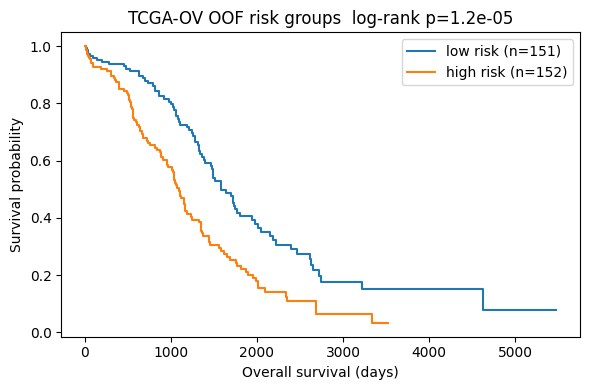

log-rank p=1.198e-05


In [15]:
import matplotlib.pyplot as plt

cols = top_var(X, N_GENES)
Z_all, _, final_scaler = scale_df(X, X, cols)
df = Z_all.assign(time=time.values, event=event.values)
final_cph = CoxPHFitter(penalizer=best["penalizer"], l1_ratio=1.0)
final_cph.fit(df, duration_col="time", event_col="event", show_progress=False)
coefs = final_cph.params_.drop(labels=["time", "event"], errors="ignore")
signature = coefs[coefs.abs() > 1e-8].sort_values(key=np.abs, ascending=False)
print(f"signature size: {len(signature)} genes")
print(signature.head(15).to_string())

high = expr_risk >= expr_risk.median()
km = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(6, 4))
for label, mask in [("low risk", ~high), ("high risk", high)]:
    km.fit(time[mask], event[mask], label=f"{label} (n={int(mask.sum())})")
    km.plot(ax=ax, ci_show=False)
lr = logrank_test(time[high], time[~high], event[high], event[~high])
ax.set_xlabel("Overall survival (days)")
ax.set_ylabel("Survival probability")
ax.set_title(f"TCGA-OV OOF risk groups  log-rank p={lr.p_value:.3g}")
plt.tight_layout()
plt.show()
print(f"log-rank p={lr.p_value:.4g}")


## 7. External validation (GSE26712, GSE14764)

Both are Affymetrix U133A (GPL96). Probes are averaged to gene symbols, then
the TCGA signature is scored after a **within-cohort** z-score so RNA-seq and
microarray scales are not mixed. C-index is computed on that cohort's own
follow-up — time units do not have to match.

GSE26712 includes 10 normal HOSE samples; those are dropped.


In [16]:
probe_to_gene = ce.gpl_gene_map("GPL96")
print(f"GPL96 mapped probes: {probe_to_gene.shape[0]}")


def apply_signature(Xg, signature):
    common = signature.index.intersection(Xg.columns)
    Z = Xg[common].copy()
    std = Z.std(axis=0, ddof=0).replace(0, np.nan)
    Z = (Z - Z.mean(axis=0)) / std
    lp = Z.fillna(0) @ signature.loc[common]
    return lp, common


def eval_geo(slug, *, tumor_col, tumor_val, time_col, event_col,
             time_scale, event_positive=None):
    expr, pheno = ce.load_geo(slug)
    keep = pheno[tumor_col].astype(str).eq(tumor_val) if tumor_col else pd.Series(True, index=pheno.index)
    samples = expr.columns.intersection(pheno.index[keep])
    Xp = expr[samples].T
    Xg = ce.collapse_to_genes(Xp, probe_to_gene)
    t = pd.to_numeric(pheno.loc[samples, time_col], errors="coerce") * time_scale
    if event_positive is None:
        e = pd.to_numeric(pheno.loc[samples, event_col], errors="coerce")
    else:
        e = pheno.loc[samples, event_col].astype(str).str.startswith(event_positive).astype(float)
    ok = t.notna() & e.notna() & (t >= 1)
    t, e, Xg = t[ok], e[ok].astype(int), Xg.loc[ok]
    lp, genes = apply_signature(Xg, signature)
    ci = cindex(t, e, lp)
    hi = lp >= lp.median()
    p = logrank_test(t[hi], t[~hi], e[hi], e[~hi]).p_value
    out = {
        "dataset": slug,
        "n_samples": int(len(t)),
        "n_events": int(e.sum()),
        "n_signature_genes_present": int(len(genes)),
        "cindex": float(ci),
        "logrank_p": float(p),
    }
    print(out)
    return out, lp, t, e


ext_bonome, _, _, _ = eval_geo(
    "gse26712-ovarian-expression-series-matrix",
    tumor_col="source_name_ch1", tumor_val="Ovarian tumor",
    time_col="survival years", event_col="status",
    time_scale=365.25, event_positive="DOD",
)
ext_cnb, _, _, _ = eval_geo(
    "gse14764-ovarian-expression-series-matrix",
    tumor_col=None, tumor_val="",
    time_col="overall survival time", event_col="overall survival event",
    time_scale=30.437, event_positive=None,
)


GPL96 mapped probes: 21156
{'dataset': 'gse26712-ovarian-expression-series-matrix', 'n_samples': 185, 'n_events': 129, 'n_signature_genes_present': 124, 'cindex': 0.5597882809005517, 'logrank_p': 0.6772810253238479}
{'dataset': 'gse14764-ovarian-expression-series-matrix', 'n_samples': 80, 'n_events': 21, 'n_signature_genes_present': 124, 'cindex': 0.5298885511651469, 'logrank_p': 0.8811430216036636}


## 8. Save the run

Prints the record between markers so it can be harvested from this notebook's
saved output after you **save the file**:

```bash
.venv/bin/python agent/scripts/colab_runs.py --import-notebook notebooks/ovarian-os-lasso-cox.ipynb
.venv/bin/python agent/scripts/colab_runs.py --last
```


In [17]:
payload = {
    "task": "tcga-ov lasso-cox overall survival",
    "train": meta,
    "clinical_oof_cindex": clin_cindex,
    "clinical_n": int(len(clin_keep)),
    "expression_oof_cindex": expr_cindex,
    "penalizer": best["penalizer"],
    "n_genes_considered": N_GENES,
    "signature_size": int(len(signature)),
    "signature_top": {k: float(v) for k, v in signature.head(20).items()},
    "os3y_oof_auc": auc3,
    "tcga_logrank_p": float(lr.p_value),
    "external": {"gse26712": ext_bonome, "gse14764": ext_cnb},
}
run_dir = ce.save_run("tcga-ov-lasso-cox", payload)
print(run_dir)

print("===RUN-RECORD-BEGIN===")
print((run_dir / "run.json").read_text().strip())
print("===RUN-RECORD-END===")
print(ce.push_runs())


/content/research/.research/colab/runs/20260824T195053Z-tcga-ov-lasso-cox
===RUN-RECORD-BEGIN===
{
  "name": "tcga-ov-lasso-cox",
  "saved_at": "20260824T195053Z",
  "env": {
    "colab": true,
    "python": "3.13.15",
    "workspace": "/content/research",
    "workspace_present": true,
    "cpu_count": 2,
    "ram_gb": 13.6,
    "disk_free_gb": 69.9,
    "gpu": {
      "available": true,
      "name": "Tesla T4",
      "memory_mb": 15360,
      "driver": "580.82.07",
      "torch_cuda": true,
      "torch_version": "2.11.0+cu128"
    }
  },
  "result": {
    "task": "tcga-ov lasso-cox overall survival",
    "train": {
      "dataset": "tcga-ov-xena-rna-seq-hiseqv2",
      "clinical": "tcga-ov-xena-clinical-matrix",
      "n_samples": 303,
      "n_features": 20530,
      "n_events": 182,
      "n_censored": 121,
      "median_followup_days": 951.0,
      "dropped_nonprimary": 4
    },
    "clinical_oof_cindex": 0.6147105948327659,
    "clinical_n": 266,
    "expression_oof_cindex": 0.